# Report turbulence-CTD on 26-28 Nov 2025

Includes VMP and CTD profiles at 3 locations (South Basin, Central Constriction, Western Constriction)

In [13]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), r"../../../scripts/functions/figures")))
from functions_figures import array_bands, get_cmap_discrete, compute_logmedian_list
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), r"../../../scripts/functions/ctd")))
from functions_ctd import thorpe_scale
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), r"../../../scripts/functions/general_functions")))
from general_functions import read_netCDF_xr, datenum2timestamp, concat_datasets_by_coords
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import cmocean
import xarray as xr
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font
plt.close('all')

### Specify if using Renku or not:

In [14]:
using_Renku = False

In [15]:
if using_Renku:
    datafolder=os.path.join('..','..','..','..','data-lakezug')   
else:
    datafolder=os.path.join('..','..','..','data')
    # For interactive plots in Jupyter Notebook 
    %matplotlib widget     

Parameters

In [78]:
#%% Specify field campaign here:
campaign_name='20251128'
datalevel='Level2'
instrument='VMP'
categories=['VMPS','VMPC','VMPW'] # Among profile names (VMP & CTD)
colcat=[[50/255,100/255,214/255],[1, 0.4, 0.15],[0.1, 0.6, 0.3]]
colcat_light=[[140/255,170/255,230/255],[1, 0.75, 0.6],[0.5,0.8,0.5]]

# Relative path:
data_folder_rel=os.path.join(datafolder,instrument,campaign_name,datalevel)

#folder_param_name='down1.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman'
fileprof=[f for f in os.listdir(data_folder_rel) if f.endswith('.nc')]

# CTD transect:
# data_folder_rel_CTD=os.path.join('..','..','..','scripts','data_analysis','2-Process_transect')
#  fileCTD='CTD_transect_'+campaign_name+'.nc'

# Individual profiles:
data_folder_rel_CTD=os.path.join(datafolder,'CTD',campaign_name,'Level2')
fileCTDprof=[f for f in os.listdir(data_folder_rel_CTD) if f.endswith('.nc')]

savefig=True

colmicro=plt.get_cmap('viridis',len(fileprof))
colCTD=plt.get_cmap('viridis', len(fileCTDprof))

white_color_fraction=0.8
whitecol=np.array([1,1,1,1])



Load the data

In [79]:
# Bathymetry:
data_bathy=read_netCDF_xr(os.path.join(datafolder,'Bathymetry','Level2','bathymetry_Zug_10m.nc'))

# VMP profiles:
dataprof=[]
datetime_micro=[]
profnames=[]
for kf in range(len(fileprof)):
    filename_nolevel=fileprof[kf][fileprof[kf].find('_')+1:]
    if datalevel=='Level1':
        filename_full='L1_'+filename_nolevel
    elif datalevel=='Level2' or datalevel=='Level2_Qdrive':
        filename_full='L2_'+filename_nolevel
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))
    datetime_micro.append(pd.to_datetime(datenum2timestamp(dataprof[kf].SLOW_datenum.values[0])+dataprof[kf].SLOW_dtsec.values[0], unit='s'))
    profnames.append(dataprof[kf].profname)

if campaign_name=='20251126':
    # VMP005 contains one profile that was divided into two by the script (due to profile stopping): combine the two profiles
    indVMP005=np.where(np.array([data.filename for data in dataprof])=='VMP005')[0]
    #indVMP005=np.array([2,3])   
    dataprof[indVMP005[0]]=concat_datasets_by_coords(dataprof[indVMP005[0]], dataprof[indVMP005[1]], ["BINNED_depth","SLOW_dtsec","FAST_dtsec"])
    dataprof.pop(indVMP005[1]) 
    datetime_micro.pop(indVMP005[1])
    profnames.pop(indVMP005[1])
    fileprof.pop(indVMP005[1])
if campaign_name=='20251128':
    indVMP002=np.where(np.array([data.filename for data in dataprof])=='VMP002')[0] 
    dataprof[indVMP002[0]]=concat_datasets_by_coords(dataprof[indVMP002[0]], dataprof[indVMP002[1]], ["BINNED_depth","SLOW_dtsec","FAST_dtsec"])
    dataprof.pop(indVMP002[1]) 
    datetime_micro.pop(indVMP002[1])
    profnames.pop(indVMP002[1])
    fileprof.pop(indVMP002[1])

indcat=[np.where(np.array(profnames)==catname)[0] for catname in categories]

#%% CTD transect:
# dataprof_CTD=read_netCDF_xr(os.path.join(data_folder_rel_CTD,fileCTD))
# datetime_CTD=pd.to_datetime(dataprof_CTD.time.values, unit='s')

#%% CTD profiles:
dataprof_CTD_list=[]
datetime_CTD=[]
profnames_CTD=[]
xcoord_CTD=[]
ycoord_CTD=[]
for kf in range(len(fileCTDprof)):     
    dataprof_CTD_list.append(read_netCDF_xr(os.path.join(data_folder_rel_CTD,fileCTDprof[kf])))
    datetime_CTD.append(pd.to_datetime(dataprof_CTD_list[kf].time.values[0], unit='s'))
    profnames_CTD.append(dataprof_CTD_list[kf].attrs['Profile name'])
    xcoord_CTD.append(int(dataprof_CTD_list[kf].attrs['X Coordinate (CH1903)']))
    ycoord_CTD.append(int(dataprof_CTD_list[kf].attrs['Y Coordinate (CH1903)']))

indcat_CTD=[np.where(np.array(profnames_CTD)==catname)[0] for catname in categories]
indcat_withCTD=list(np.where([len(i)>0 for i in indcat_CTD])[0])

c:\Users\tdoda\AppData\Local\anaconda3\envs\datalakes\Lib\site-packages\xarray\core\concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))


Plot the map

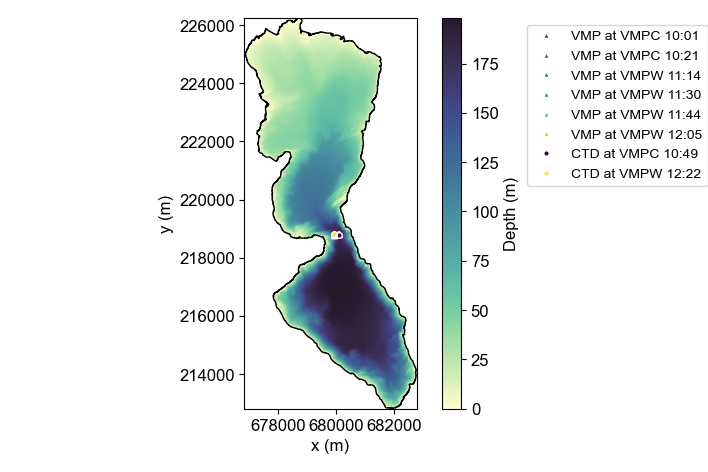

In [18]:
fig,ax = plt.subplots(1,1,figsize=(18 / 2.54, 12 / 2.54))  # Convert from cm to inches

hp=ax.pcolormesh(data_bathy.x-2e6, data_bathy.y-1e6,data_bathy.depth,vmin=0,vmax=np.nanmax(data_bathy.depth),cmap="cmo.deep")
ax.plot(data_bathy.x_contour-2e6, data_bathy.y_contour-1e6, color='k', linewidth=1)
ax.set_aspect("equal")
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
cb = fig.colorbar(hp, ax=ax)
cb.set_label('Depth (m)')

# Add the microCTD profiles:
for kf in range(len(fileprof)):
    if 'x_coord' in dataprof[kf].attrs.keys() and 'y_coord' in dataprof[kf].attrs.keys():
        ax.plot(int(dataprof[kf].x_coord), int(dataprof[kf].y_coord), marker='^', linestyle='', color=colmicro(kf), markersize=4, 
                markeredgecolor='w',markeredgewidth=1,label='VMP at '+profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))

# Add the CTD profiles:
for kCTD in range(len(dataprof_CTD_list)):
    ax.plot(xcoord_CTD[kCTD], ycoord_CTD[kCTD], marker='o', linestyle='', color=colCTD(kCTD), markersize=4, 
            markeredgecolor='w',markeredgewidth=1,label='CTD at '+profnames_CTD[kCTD]+' '+str(datetime_CTD[kCTD].strftime('%H:%M')))

ax.legend(loc='upper left',bbox_to_anchor=(1.6, 1), fontsize=10)

fig.set_tight_layout(True)

Plot the VMP profiles

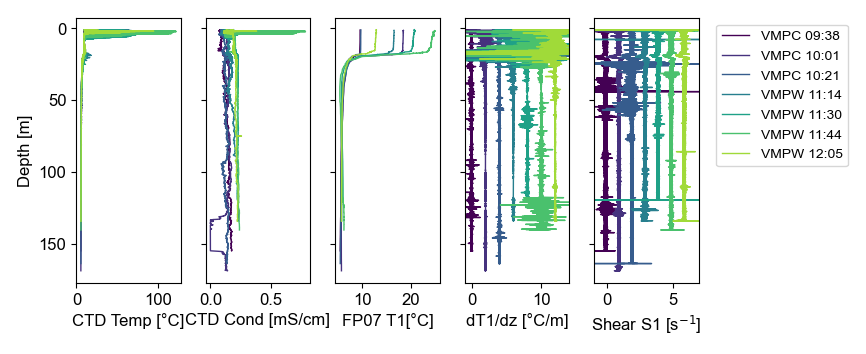

In [25]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T1'

for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature.data,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf].SLOW_conductivity20.data/1000,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['FAST_fast_'+Tsensor].data,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf]['FAST_grad_'+Tsensor].data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[4].plot(dataprof[kf].FAST_fast_S1.data+kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf),label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax[1].set_xlabel('CTD Cond [mS/cm]')
ax[2].set_xlabel('FP07 '+Tsensor+'[°C]')
ax[3].set_xlabel('d'+Tsensor+'/dz [°C/m]')
ax[4].set_xlabel('Shear S1 [s$^{-1}$]')

ax[3].set_xlim(-1,2*len(dataprof))
ax[4].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

ax[4].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_prof_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_prof_'+campaign_name+'.svg',dpi=400)

fig.set_tight_layout(True)

Plot the turbulence data from the VMP profiles

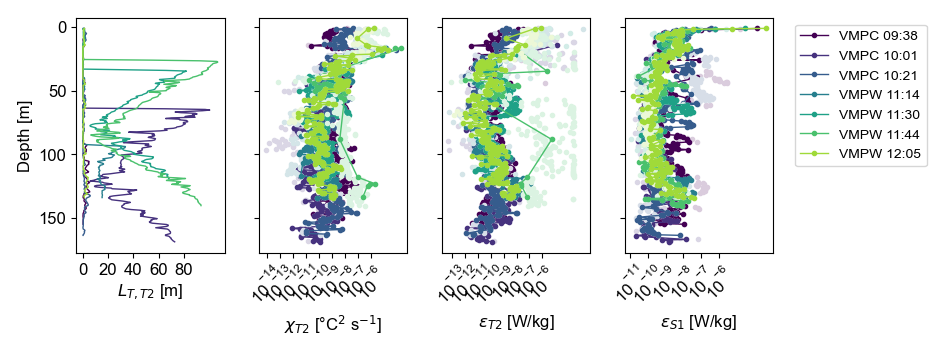

In [42]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(24 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T2'

for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colmicro(kf))
    
    indkeep_T=np.where(dataprof[kf]['BINNED_flag_'+Tsensor].data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf]['BINNED_LTu'+Tsensor].data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colmicro(kf),label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_{T,'+Tsensor+'}$ [m]')
ax[1].set_xlabel('$\\chi_{'+Tsensor+'}$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{'+Tsensor+'}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 20))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_turbulence_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_'+campaign_name+'.svg',dpi=400)



Plot averaged turbulence profiles

In [80]:
# Compute log-median profiles for the different categories, by keeping only bins without flags:
depthcell=10 # [m]

plot_data=dict()
varlogmed=["LTu","eps_","Xi_","KOsbornCox_"]
indcat_withturb=[]
for var in varlogmed:
    plot_data[var]={"depth_all":[], "values_all":[], "depth_cells":[], "logmed":[]}
    for kcat in range(len(categories)):
        if len(indcat[kcat])>0: # At least one profile in this category
            if var==varlogmed[0]: 
                indcat_withturb.append(kcat) # Save category index
            depth_all, values_all, depth_cells, logmed = compute_logmedian_list([dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]],[dataprof[i]["BINNED_"+var+"T1"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]], depthcell)
            # Include both T1 and T2:
            #depth_all, values_all, depth_cells, logmed = compute_logmedian_list([dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]],
                                                                            # [dataprof[i]["BINNED_"+var+'T1'].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_"+var+'T2'].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]], depthcell)
            plot_data[var]["depth_all"].append(depth_all)
            plot_data[var]["values_all"].append(values_all)
            plot_data[var]["depth_cells"].append(depth_cells)
            plot_data[var]["logmed"].append(logmed)

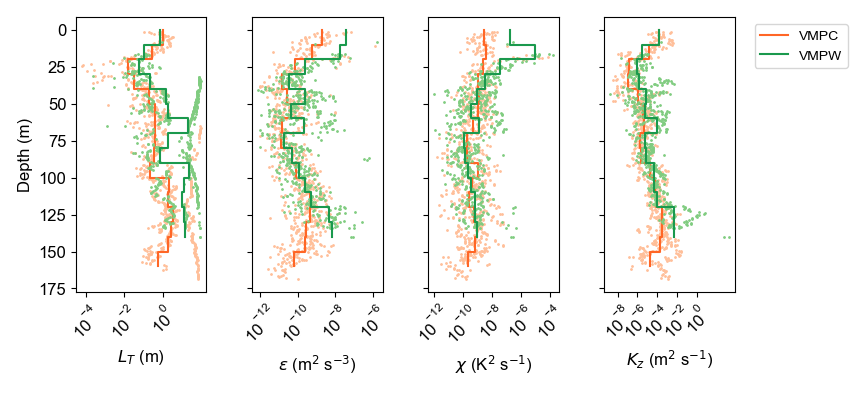

In [81]:

#depthmax=180 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches

# 1st subplot: Thorpe-T1
for kcat in range(len(indcat_withturb)):
        ax[0].plot(plot_data["LTu"]["values_all"][kcat], plot_data["LTu"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
        ax[0].plot(10**plot_data["LTu"]["logmed"][kcat], plot_data["LTu"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]])
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel(r'$L_{T}$ (m)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 2))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)

# 2nd subplot: Eps-T1
for kcat in range(len(indcat_withturb)):
        ax[1].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
        ax[1].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]])
ax[1].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 2))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-11), 10**(-4)])


# 3rd subplot: X-T1
for kcat in range(len(indcat_withturb)):
        ax[2].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
        ax[2].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]])
ax[2].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 4th subplot: Kz-T1
for kcat in range(len(indcat_withturb)):
        ax[3].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
        ax[3].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]])
ax[3].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)


#ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_'+campaign_name+'.svg',dpi=1000)



Plot CTD profiles

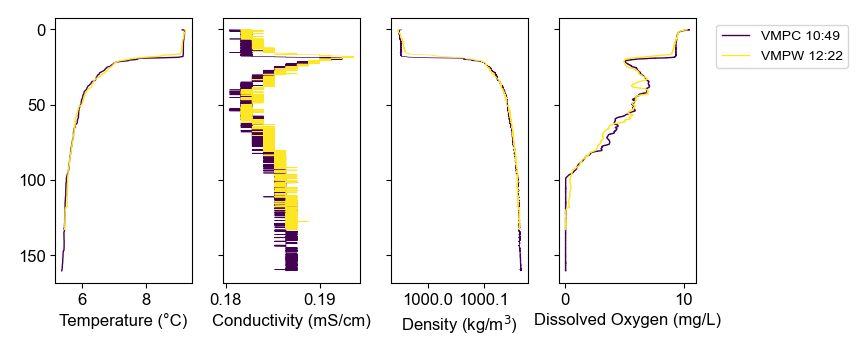

In [43]:

fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD_list)):
    ax[0].plot(dataprof_CTD_list[kprof]["Temp"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=1)
    ax[1].plot(dataprof_CTD_list[kprof]["Cond"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[2].plot(dataprof_CTD_list[kprof]["rho"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[3].plot(dataprof_CTD_list[kprof]["DO_mg"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=1,label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
    
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Conductivity (mS/cm)')
ax[2].set_xlabel('Density (kg/m$^3$)')
ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_'+campaign_name+'.svg',dpi=1000)

    


Plot temp-DO profiles or density-DO profiles

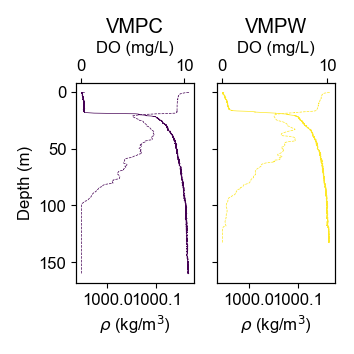

In [44]:

fig,ax = plt.subplots(1,len(dataprof_CTD_list),figsize=(9 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD_list)):
    #ax[kprof].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[kprof].plot(dataprof_CTD_list[kprof]["rho"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax2=ax[kprof].twiny()
    ax2.plot(dataprof_CTD_list[kprof]["DO_mg"].values, dataprof_CTD_list[kprof]["depth"].values, '--', color=colCTD(kprof), linewidth=0.5)
    
    #ax[kprof].set_xlabel('T (°C)')
    ax[kprof].set_xlabel('$\\rho$ (kg/m$^3$)')
    ax2.set_xlabel('DO (mg/L)')
    ax[kprof].set_title(profnames_CTD[kprof])
    ax[kprof].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[0].invert_yaxis()  # Reverse the y-axis
ax[0].set_ylabel('Depth (m)') 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.svg',dpi=1000)



Plot turbulence and DO on the same figure

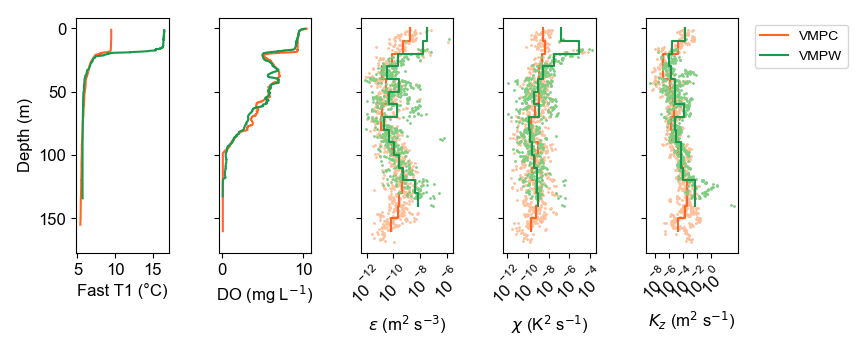

In [83]:


# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


# 1st plot: fast temperature
for kcat in range(len(indcat_withturb)):
    ax[0].plot(dataprof[indcat[indcat_withturb[kcat]][0]].FAST_fast_T1.data,dataprof[indcat[indcat_withturb[kcat]][0]].FAST_depth,linewidth=1.5, color=colcat[indcat_withturb[kcat]])
ax[0].set_xlabel('Fast T1 (°C)')

# 2nd subplot: DO
for kcat in range(len(indcat_withCTD)):
    ax[1].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["DO_mg"],dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],'-',linewidth=1.5, color=colcat[indcat_withCTD[kcat]])
ax[1].set_xlabel('DO (mg L$^{-1}$)')


# 2nd subplot: Eps-T1
for kcat in range(len(indcat_withturb)):
    ax[2].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[2].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]])
ax[2].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
for kcat in range(len(indcat_withturb)):
    ax[3].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[3].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]]) 
ax[3].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
for kcat in range(len(indcat_withturb)):
    ax[4].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[4].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]])
ax[4].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[4].set_xscale('log')
xlimval=ax[4].get_xlim()
ax[4].set_xticks(10.0**np.arange(-14, 1, 2))
ax[4].set_xlim(xlimval)
ax[4].tick_params(axis='x', labelrotation=45)
ax[4].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)
ax[0].set_ylabel('Depth (m)')

ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_DO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_DO_'+campaign_name+'.svg',dpi=400)